# DAT 402 Project 2: Breast Cancer Classification

This project uses the Breast Cancer Wisconsin dataset to predict whether a tumor is benign or malignant based on measured tumor characteristics. Two classification methods are compared: K-Nearest Neighbors (KNN) and Logistic Regression. The goal is to evaluate which model performs better on this dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Data Loading and Description

The Breast Cancer Wisconsin dataset contains measurements describing breast tumors, including radius, texture, perimeter, area, smoothness, compactness, concavity, and other related characteristics. The target variable is `diagnosis`, which identifies each tumor as either benign or malignant.

The dataset contains 569 observations and 31 columns, including 30 predictor variables and one diagnosis variable.

Dataset source: UCI Machine Learning Repository – Breast Cancer Wisconsin (Diagnostic)  
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [2]:
df = pd.read_csv("breast_cancer_wisconsin (1).csv")

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 2. Data Inspection and Cleaning

The dataset was inspected to determine its size, variable types, and whether any missing values were present. The dataset contains 569 rows and 31 columns. The predictor variables are numeric, while the diagnosis variable is categorical.

No missing values were found, so no rows needed to be removed or filled in.

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (569, 31)

Columns:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis'],
      dtype='object')

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64

### Diagnosis Distribution

The dataset contains 357 benign tumors and 212 malignant tumors. Approximately 62.7% of the observations are benign and 37.3% are malignant.

There are more benign cases than malignant cases, but both diagnosis groups contain enough observations for analysis.

In [4]:
print("Total missing values:", df.isnull().sum().sum())

print("\nDiagnosis counts:")
print(df["diagnosis"].value_counts())

print("\nDiagnosis percentages:")
print(df["diagnosis"].value_counts(normalize=True) * 100)

Total missing values: 0

Diagnosis counts:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Diagnosis percentages:
diagnosis
benign       62.741652
malignant    37.258348
Name: proportion, dtype: float64


### Diagnosis Visualization

The following bar chart shows the number of benign and malignant observations. Benign tumors occur more frequently in the dataset than malignant tumors.

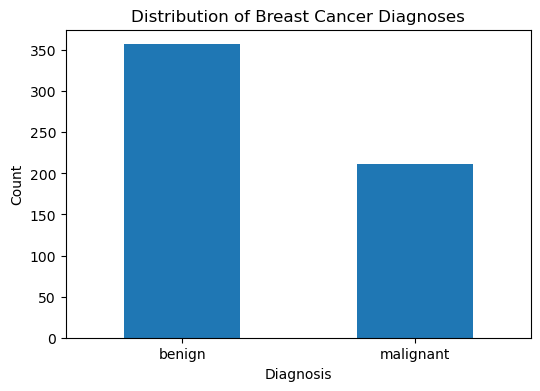

In [5]:
plt.figure(figsize=(6,4))

df["diagnosis"].value_counts().plot(kind="bar")

plt.title("Distribution of Breast Cancer Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

## 3. Exploratory Data Analysis

The relationship between tumor characteristics and diagnosis was explored using several visualizations.

The boxplot below compares mean tumor radius between benign and malignant tumors. Malignant tumors generally have larger mean radius values than benign tumors. This suggests that mean radius may be useful for distinguishing between the two diagnosis groups.

<Figure size 700x500 with 0 Axes>

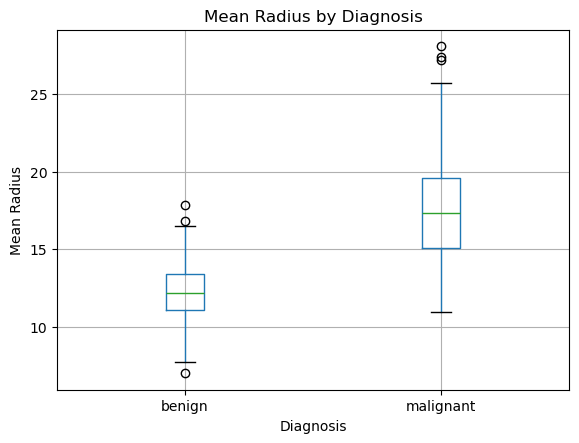

In [6]:
plt.figure(figsize=(7,5))

df.boxplot(column="mean radius", by="diagnosis")

plt.title("Mean Radius by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Radius")

plt.show()

### Mean Radius vs. Mean Texture

The scatterplot compares mean radius and mean texture for benign and malignant tumors.

There is some overlap between the two diagnosis groups, but malignant tumors generally have larger mean radius values and often higher mean texture values. This suggests that using multiple tumor measurements together may help predict diagnosis.

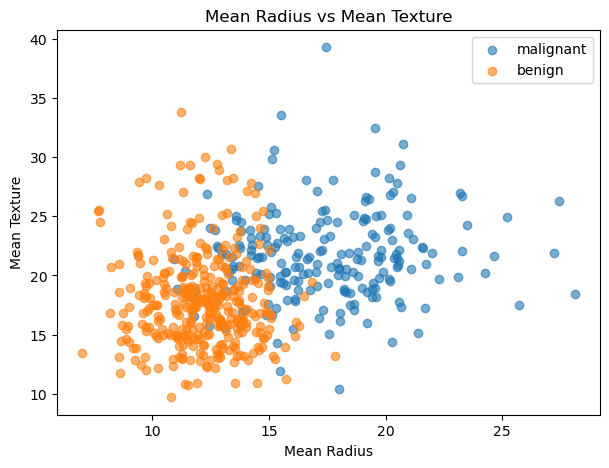

In [7]:
plt.figure(figsize=(7,5))

for diagnosis in df["diagnosis"].unique():
    subset = df[df["diagnosis"] == diagnosis]
    plt.scatter(
        subset["mean radius"],
        subset["mean texture"],
        label=diagnosis,
        alpha=0.6
    )

plt.title("Mean Radius vs Mean Texture")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.legend()

plt.show()

## 4. Data Preparation

The `diagnosis` column was selected as the target variable. The remaining 30 tumor measurements were used as predictor variables.

The goal is to use these tumor characteristics to predict whether an observation is benign or malignant.

In [8]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


### Training and Testing Sets

The dataset was divided into training and testing sets using an 80/20 split. The training data are used to fit the models, while the testing data are used to evaluate how well the models perform on observations they have not seen before.

Stratification was used to maintain similar proportions of benign and malignant cases in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


### Feature Standardization

The predictor variables have different numerical scales, so the features were standardized before fitting the models.

Standardization is especially important for K-Nearest Neighbors because KNN uses distances between observations when determining the nearest neighbors.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (455, 30)
Testing data scaled: (114, 30)


## 5. K-Nearest Neighbors

K-Nearest Neighbors (KNN) is a classification method that predicts the class of an observation based on the classes of nearby observations.

Values of `k` from 1 through 20 were tested to determine which number of neighbors produced the highest classification accuracy.

In [11]:
knn_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    score = knn.score(X_test_scaled, y_test)
    knn_scores.append(score)

best_k = np.argmax(knn_scores) + 1

print("Best k:", best_k)
print("Best accuracy:", knn_scores[best_k - 1])

Best k: 5
Best accuracy: 0.956140350877193


### Selecting the Best k Value

The highest test accuracy occurred at `k = 5` and `k = 7`. Because the code selected the first value with the maximum accuracy, `k = 5` was selected for the final KNN model.

The best KNN accuracy was approximately 95.6%.

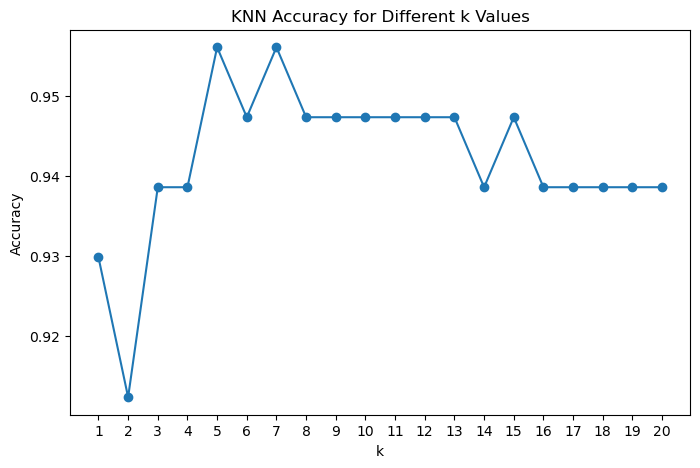

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(1, 21), knn_scores, marker="o")

plt.title("KNN Accuracy for Different k Values")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))

plt.show()

### Final KNN Model

The final KNN classifier was trained using `k = 5`. Predictions were then made using the testing set to evaluate the model's performance.

In [13]:
final_knn = KNeighborsClassifier(n_neighbors=5)

final_knn.fit(X_train_scaled, y_train)

knn_predictions = final_knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_predictions))

print("\nClassification Report:")
print(classification_report(y_test, knn_predictions))

KNN Accuracy: 0.956140350877193

Confusion Matrix:
[[71  1]
 [ 4 38]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.95      0.99      0.97        72
   malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 6. Logistic Regression

Logistic Regression was used as the second classification method. Logistic Regression estimates the probability that an observation belongs to a particular category based on the predictor variables.

The same training and testing data were used so that its performance could be compared directly with KNN.

In [14]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

log_predictions = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_predictions))

print("\nClassification Report:")
print(classification_report(y_test, log_predictions))

Logistic Regression Accuracy: 0.9649122807017544

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        72
   malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 7. Model Comparison

Both classification methods performed well. However, Logistic Regression produced slightly better results.

KNN achieved approximately 95.6% accuracy, while Logistic Regression achieved approximately 96.5% accuracy.

Logistic Regression also correctly classified one additional malignant tumor and had higher recall for the malignant class. Based on these results, Logistic Regression performed slightly better than KNN on this dataset.

In [15]:
comparison = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, knn_predictions),
        accuracy_score(y_test, log_predictions)
    ]
})

comparison

,Model,Accuracy
0,KNN,0.956140
1,Logistic Regression,0.964912


### Accuracy Comparison

The following graph compares the overall classification accuracy of the two models. Both achieved accuracy above 95%, with Logistic Regression producing the higher value.

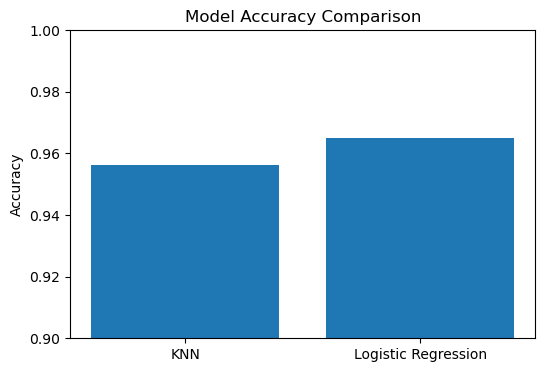

In [16]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)

plt.show()

### KNN Results

The KNN model achieved approximately 95.6% accuracy.

It correctly classified 71 benign tumors and 38 malignant tumors. It incorrectly classified 1 benign tumor and 4 malignant tumors.

The recall for malignant tumors was 0.90, meaning that approximately 90% of the malignant tumors in the testing set were correctly identified.

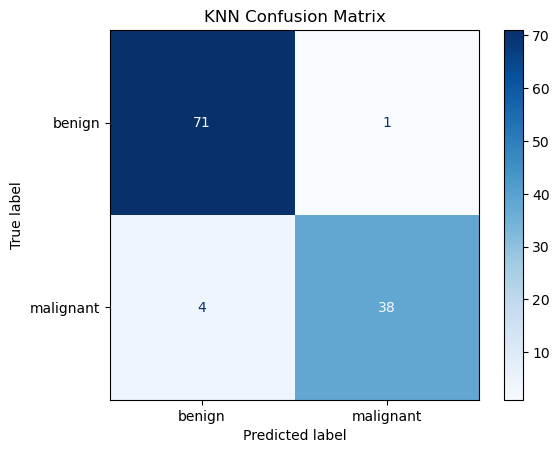

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.show()

### Logistic Regression Results

The Logistic Regression model achieved approximately 96.5% accuracy.

It correctly classified 71 benign tumors and 39 malignant tumors. It incorrectly classified 1 benign tumor and 3 malignant tumors.

The recall for malignant tumors was 0.93, meaning that approximately 93% of the malignant cases in the testing set were correctly identified.

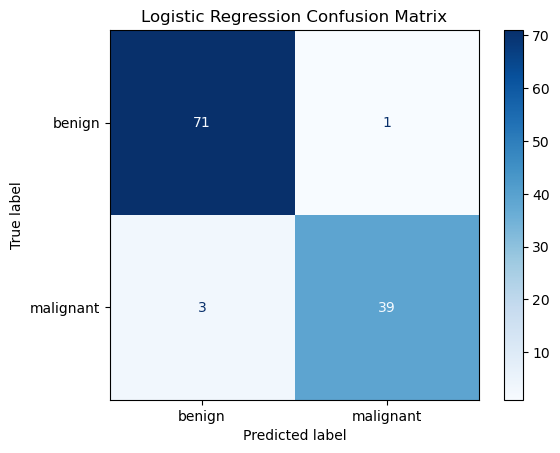

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_predictions,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

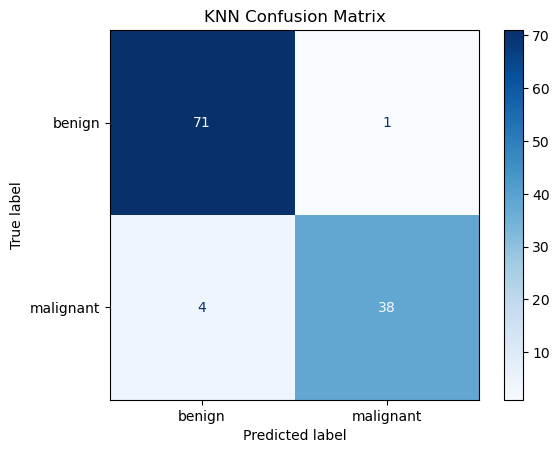

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.show()

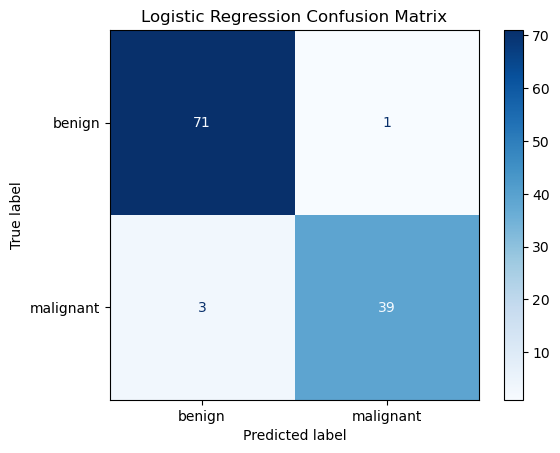

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_predictions,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 8. Conclusion

Both K-Nearest Neighbors and Logistic Regression performed well when predicting whether breast tumors were benign or malignant.

KNN achieved approximately 95.6% accuracy, while Logistic Regression achieved approximately 96.5% accuracy. Logistic Regression also achieved better recall for malignant tumors and made one fewer error when identifying malignant cases.

Overall, Logistic Regression was the better-performing model in this analysis, although both methods demonstrated that tumor measurements can be useful for predicting breast cancer diagnosis.